In [1]:
!pip install pandas matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print(" All libraries imported successfully")

 All libraries imported successfully


In [4]:
df = pd.read_csv('global_superstore.csv', encoding='latin-1')

print(f" File loaded!")
print(f"   Rows    : {len(df):,}")
print(f"   Columns : {len(df.columns)}")

 File loaded!
   Rows    : 9,800
   Columns : 18


In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
print(f"Shape: {df.shape}\n")
print("All columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:02d}. {col:<25s} [{df[col].dtype}]")

Shape: (9800, 18)

All columns:
  01. Row ID                    [int64]
  02. Order ID                  [object]
  03. Order Date                [object]
  04. Ship Date                 [object]
  05. Ship Mode                 [object]
  06. Customer ID               [object]
  07. Customer Name             [object]
  08. Segment                   [object]
  09. Country                   [object]
  10. City                      [object]
  11. State                     [object]
  12. Postal Code               [float64]
  13. Region                    [object]
  14. Product ID                [object]
  15. Category                  [object]
  16. Sub-Category              [object]
  17. Product Name              [object]
  18. Sales                     [float64]


In [7]:
print("=" * 50)
print("  NULL COUNTS")
print("=" * 50)
nulls = df.isnull().sum()
if nulls.sum() == 0:
    print("   No nulls found!")
else:
    print(nulls[nulls > 0].to_string())

print(f"\n  Duplicate rows : {df.duplicated().sum():,}")

  NULL COUNTS
Postal Code    11

  Duplicate rows : 0


In [8]:
print("NUMERIC COLUMN RANGES")
print("=" * 50)
print(f"  Sales    : ${df['Sales'].min():.2f}  to  ${df['Sales'].max():,.2f}")
print(f"  Avg Sale : ${df['Sales'].mean():,.2f}")

print("\nCATEGORICAL COLUMNS")
print("=" * 50)
for col in ['Ship Mode', 'Segment', 'Region', 'Category']:
    print(f"  {col:<15s}: {sorted(df[col].dropna().unique().tolist())}")

NUMERIC COLUMN RANGES
  Sales    : $0.44  to  $22,638.48
  Avg Sale : $230.77

CATEGORICAL COLUMNS
  Ship Mode      : ['First Class', 'Same Day', 'Second Class', 'Standard Class']
  Segment        : ['Consumer', 'Corporate', 'Home Office']
  Region         : ['Central', 'East', 'South', 'West']
  Category       : ['Furniture', 'Office Supplies', 'Technology']


In [10]:
df[['Sales']].describe().round(2)

,Sales
count,9800.00
mean,230.77
std,626.65
min,0.44
25%,17.25
50%,54.49
75%,210.60
max,22638.48


In [11]:
df = df.rename(columns={
    'Row ID'        : 'row_id',
    'Order ID'      : 'order_id',
    'Order Date'    : 'order_date',
    'Ship Date'     : 'ship_date',
    'Ship Mode'     : 'ship_mode',
    'Customer ID'   : 'customer_id',
    'Customer Name' : 'customer_name',
    'Segment'       : 'segment',
    'Country'       : 'country',
    'City'          : 'city',
    'State'         : 'state',
    'Postal Code'   : 'postal_code',
    'Region'        : 'region',
    'Product ID'    : 'product_id',
    'Category'      : 'category',
    'Sub-Category'  : 'sub_category',
    'Product Name'  : 'product_name',
    'Sales'         : 'sales',
})

print(" Columns renamed to snake_case!")
print(df.columns.tolist())

 Columns renamed to snake_case!
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales']


In [12]:
# Postal Code has 11 nulls — fill with 0
before = df['postal_code'].isnull().sum()
df['postal_code'] = df['postal_code'].fillna(0).astype(int)

print(f" Fixed postal_code nulls: {before} → 0")
print(f"   Remaining nulls : {df.isnull().sum().sum()}")

 Fixed postal_code nulls: 11 → 0
   Remaining nulls : 0


In [13]:
# Dates are in DD/MM/YYYY format in global superstore
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce')
df['ship_date']  = pd.to_datetime(df['ship_date'],  dayfirst=True, errors='coerce')

bad = df['order_date'].isnull().sum()
if bad > 0:
    print(f"  Dropping {bad} rows with bad dates")
    df = df.dropna(subset=['order_date'])

print(f" Dates parsed!")
print(f"   Date range : {df['order_date'].min().date()}  to  {df['order_date'].max().date()}")

 Dates parsed!
   Date range : 2015-01-03  to  2018-12-30


In [14]:
df['order_year']       = df['order_date'].dt.year
df['order_month']      = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.strftime('%b')
df['order_quarter']    = 'Q' + df['order_date'].dt.quarter.astype(str)
df['order_day_name']   = df['order_date'].dt.day_name()
df['is_weekend_order'] = (df['order_date'].dt.dayofweek >= 5).astype(int)
df['days_to_ship']     = (df['ship_date'] - df['order_date']).dt.days

print(" Date columns derived!")
print(f"   Years in data  : {sorted(df['order_year'].unique().tolist())}")
print(f"   Avg ship days  : {df['days_to_ship'].mean():.1f}")
print(f"   Max ship days  : {df['days_to_ship'].max()}")

 Date columns derived!
   Years in data  : [2015, 2016, 2017, 2018]
   Avg ship days  : 4.0
   Max ship days  : 7


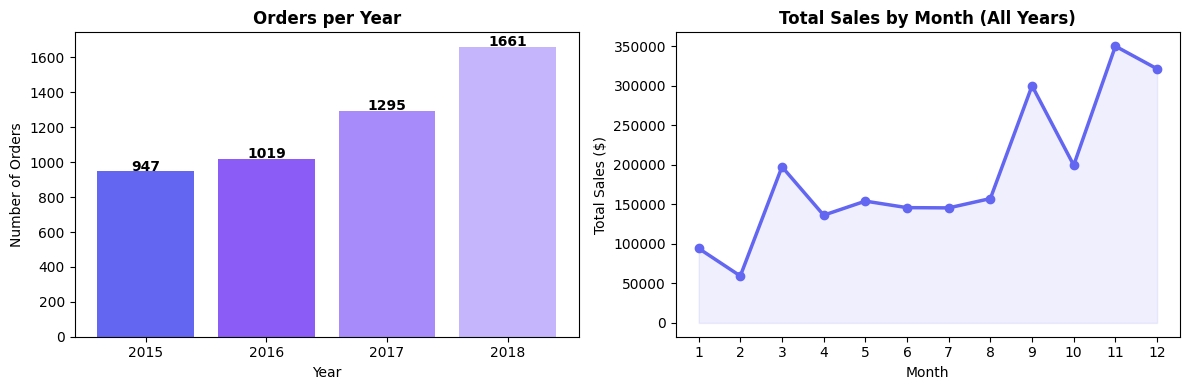

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Orders per year
year_orders = df.groupby('order_year')['order_id'].nunique()
axes[0].bar(year_orders.index.astype(str), year_orders.values,
            color=['#6366f1','#8b5cf6','#a78bfa','#c4b5fd'])
axes[0].set_title('Orders per Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Orders')
for i, v in enumerate(year_orders.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Sales by month
monthly = df.groupby('order_month')['sales'].sum()
axes[1].plot(monthly.index, monthly.values, marker='o',
             color='#6366f1', linewidth=2.5)
axes[1].fill_between(monthly.index, monthly.values, alpha=0.1, color='#6366f1')
axes[1].set_title('Total Sales by Month (All Years)', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Sales ($)')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [16]:
checks = {
    'No nulls in sales'       : df['sales'].isnull().sum() == 0,
    'All sales positive'      : (df['sales'] > 0).all(),
    'Ship date >= order date' : (df['days_to_ship'] >= 0).all(),
    'No nulls in order_date'  : df['order_date'].isnull().sum() == 0,
}

for check, result in checks.items():
    print(f"  {' PASS' if result else ' FAIL'}  {check}")

   PASS  No nulls in sales
   PASS  All sales positive
   PASS  Ship date >= order date
   PASS  No nulls in order_date


In [17]:
str_cols = ['ship_mode', 'segment', 'country', 'city', 'state',
            'region', 'category', 'sub_category',
            'customer_name', 'product_name']

for col in str_cols:
    df[col] = df[col].astype(str).str.strip()

print(f" Whitespace cleaned from {len(str_cols)} columns")

 Whitespace cleaned from 10 columns


In [19]:
df['sales_tier'] = pd.cut(
    df['sales'],
    bins=[0, 50, 200, 500, 1000, float('inf')],
    labels=['Micro (<$50)', 'Small ($50-200)',
            'Medium ($200-500)', 'Large ($500-1K)', 'Enterprise ($1K+)']
)

print(" Added: sales_tier")
print("\nSales Tier Distribution:")
print(df['sales_tier'].value_counts().sort_index().to_string())

 Added: sales_tier

Sales Tier Distribution:
sales_tier
Micro (<$50)         4757
Small ($50-200)      2506
Medium ($200-500)    1391
Large ($500-1K)       684
Enterprise ($1K+)     462


In [20]:
df['shipping_tier'] = pd.cut(
    df['days_to_ship'],
    bins=[-1, 0, 2, 4, 7, 100],
    labels=['Same Day', '1-2 Days', '3-4 Days',
            '5-7 Days', '7+ Days']
)

print(" Added: shipping_tier")
print(df['shipping_tier'].value_counts().sort_index().to_string())

 Added: shipping_tier
shipping_tier
Same Day     514
1-2 Days    1658
3-4 Days    3696
5-7 Days    3932
7+ Days        0


In [21]:
p95 = df['sales'].quantile(0.95)
df['is_high_value'] = (df['sales'] >= p95).astype(int)

print(f" Added: is_high_value")
print(f"   Top 5% threshold : ${p95:,.2f}")
print(f"   High value orders: {df['is_high_value'].sum():,}")

 Added: is_high_value
   Top 5% threshold : $959.98
   High value orders: 491


In [22]:
df = df.sort_values(['customer_id', 'order_date'])
df['customer_order_rank'] = df.groupby('customer_id')['order_id'] \
                              .transform(lambda x: pd.factorize(x)[0] + 1)
df['is_new_customer'] = (df['customer_order_rank'] == 1).astype(int)

print(f" Added: customer_order_rank, is_new_customer")
print(f"   New customers    : {df['is_new_customer'].sum():,}")
print(f"   Returning        : {(df['is_new_customer'] == 0).sum():,}")

 Added: customer_order_rank, is_new_customer
   New customers    : 1,648
   Returning        : 8,152


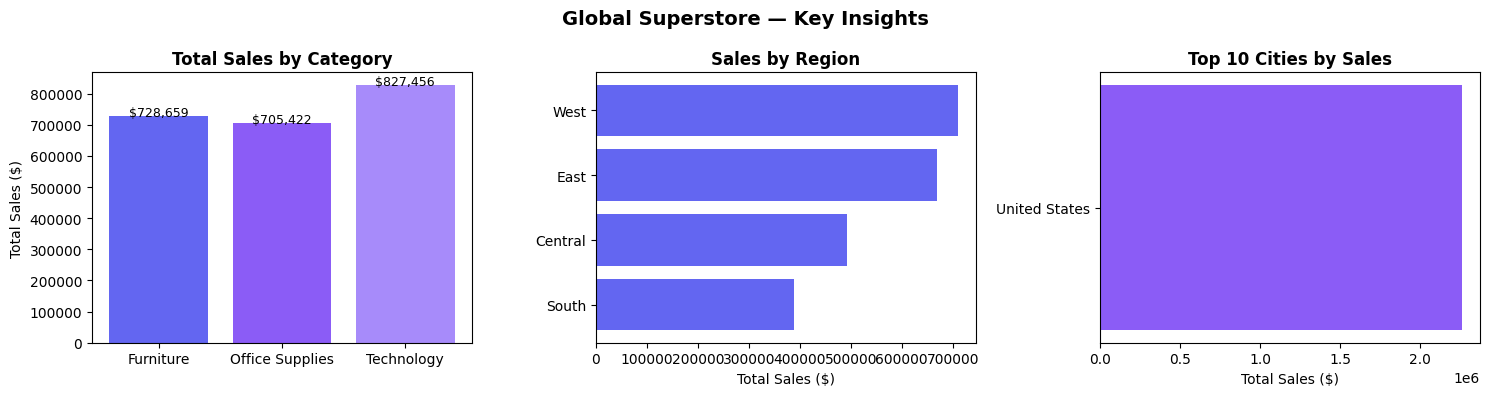

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sales by category
cat_sales = df.groupby('category')['sales'].sum()
axes[0].bar(cat_sales.index, cat_sales.values,
            color=['#6366f1','#8b5cf6','#a78bfa'])
axes[0].set_title('Total Sales by Category', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
for i, v in enumerate(cat_sales.values):
    axes[0].text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=9)

# Sales by region
reg_sales = df.groupby('region')['sales'].sum().sort_values()
axes[1].barh(reg_sales.index, reg_sales.values, color='#6366f1')
axes[1].set_title('Sales by Region', fontweight='bold')
axes[1].set_xlabel('Total Sales ($)')

top_cities = df.groupby('city')['sales'].sum() \
                  .sort_values(ascending=True).tail(10)
axes[2].barh(top_countries.index, top_countries.values, color='#8b5cf6')
axes[2].set_title('Top 10 Cities by Sales', fontweight='bold')
axes[2].set_xlabel('Total Sales ($)')

plt.suptitle('Global Superstore — Key Insights', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
seg = df.groupby('segment')['sales'].agg(['sum','count','mean']).round(2)
seg.columns = ['total_sales', 'orders', 'avg_sale']
seg['sales_share_%'] = (seg['total_sales'] / seg['total_sales'].sum() * 100).round(1)
print("Sales by Customer Segment:")
print(seg.to_string())

Sales by Customer Segment:
             total_sales  orders  avg_sale  sales_share_%
segment                                                  
Consumer      1148060.53    5101    225.07           50.8
Corporate      688494.07    2953    233.15           30.4
Home Office    424982.18    1746    243.40           18.8


In [28]:
checks = {
    'No nulls in sales'        : df['sales'].isnull().sum() == 0,
    'No nulls in order_date'   : df['order_date'].isnull().sum() == 0,
    'No nulls in postal_code'  : df['postal_code'].isnull().sum() == 0,
    'All sales positive'       : (df['sales'] > 0).all(),
    'Ship date >= order date'  : (df['days_to_ship'] >= 0).all(),
    'sales_tier exists'        : 'sales_tier' in df.columns,
    'order_year exists'        : 'order_year' in df.columns,
    'is_new_customer exists'   : 'is_new_customer' in df.columns,
    'is_high_value exists'     : 'is_high_value' in df.columns,
}

print("FINAL VALIDATION")
print("=" * 50)
all_passed = True
for check, result in checks.items():
    print(f"  {' PASS' if result else ' FAIL'}  {check}")
    if not result:
        all_passed = False

print("\n" + (" All checks passed!" if all_passed else " Fix failing checks"))

FINAL VALIDATION
   PASS  No nulls in sales
   PASS  No nulls in order_date
   PASS  No nulls in postal_code
   PASS  All sales positive
   PASS  Ship date >= order date
   PASS  sales_tier exists
   PASS  order_year exists
   PASS  is_new_customer exists
   PASS  is_high_value exists

 All checks passed!


In [29]:
print(f"Final shape : {df.shape}")
print(f"\nAll {len(df.columns)} columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:02d}. {col}")

Final shape : (9800, 30)

All 30 columns:
  01. row_id
  02. order_id
  03. order_date
  04. ship_date
  05. ship_mode
  06. customer_id
  07. customer_name
  08. segment
  09. country
  10. city
  11. state
  12. postal_code
  13. region
  14. product_id
  15. category
  16. sub_category
  17. product_name
  18. sales
  19. order_year
  20. order_month
  21. order_month_name
  22. order_quarter
  23. order_day_name
  24. is_weekend_order
  25. days_to_ship
  26. sales_tier
  27. shipping_tier
  28. is_high_value
  29. customer_order_rank
  30. is_new_customer


In [30]:
OUTPUT = 'cleaned_global_superstore.csv'
df.to_csv(OUTPUT, index=False)

print(f"File saved: {OUTPUT}")
print(f"   Rows    : {len(df):,}")
print(f"   Columns : {len(df.columns)}")
print(f"   Size    : {os.path.getsize(OUTPUT)/1024:.1f} KB")
print(f"\n Next: Load cleaned_global_superstore.csv into MySQL Workbench!")

File saved: cleaned_global_superstore.csv
   Rows    : 9,800
   Columns : 30
   Size    : 2630.5 KB

 Next: Load cleaned_global_superstore.csv into MySQL Workbench!


In [1]:
!pip install mysql-connector-python sqlalchemy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sqlalchemy import create_engine

# ── Load your cleaned CSV ──────────────────────────
df = pd.read_csv('cleaned_global_superstore.csv')

print(f" CSV loaded: {len(df):,} rows, {len(df.columns)} columns")
print(f"   Columns: {df.columns.tolist()}")

 CSV loaded: 9,800 rows, 30 columns
   Columns: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'order_year', 'order_month', 'order_month_name', 'order_quarter', 'order_day_name', 'is_weekend_order', 'days_to_ship', 'sales_tier', 'shipping_tier', 'is_high_value', 'customer_order_rank', 'is_new_customer']


In [3]:

MYSQL_USER     = 'root'
MYSQL_PASSWORD = 'iphonex@20'   # ← type your MySQL password
MYSQL_HOST     = 'localhost'
MYSQL_PORT     = '3306'
MYSQL_DB       = 'portfolio_db'

engine = create_engine(
    f'mysql+mysqlconnector://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}'
)

print("Connected to MySQL successfully!")

Connected to MySQL successfully!


In [7]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# ── Put your MySQL password here ──────────────────
MYSQL_PASSWORD = quote_plus('iphonex@20')  # ← handles special characters
MYSQL_USER     = 'root'
MYSQL_HOST     = '127.0.0.1'   # use IP instead of 'localhost'
MYSQL_PORT     = '3306'
MYSQL_DB       = 'portfolio_db'

# ── Create connection ──────────────────────────────
engine = create_engine(
    f'mysql+mysqlconnector://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}'
)

print("✅ Connected to MySQL successfully!")

✅ Connected to MySQL successfully!


In [8]:
# ── This replaces the table if it already exists ──
df.to_sql(
    name       = 'global_superstore',  # table name
    con        = engine,
    if_exists  = 'replace',            # replace existing table
    index      = False,                # don't write row numbers
    chunksize  = 1000                  # upload 1000 rows at a time
)

print(f"✅ Data loaded into MySQL!")
print(f"   Table  : global_superstore")
print(f"   Rows   : {len(df):,}")

✅ Data loaded into MySQL!
   Table  : global_superstore
   Rows   : 9,800


In [10]:
# ── Read back from MySQL to confirm ───────────────
result = pd.read_sql("SELECT COUNT(*) AS total_rows FROM global_superstore", engine)
print(f"✅ Rows in MySQL table: {result['total_rows'][0]:,}")
print(" Data is in MySQL — you can now run SQL queries!")

✅ Rows in MySQL table: 9,800
 Data is in MySQL — you can now run SQL queries!
